# Context Assembler Compare Rankings — F1 / FNR анализ

Сравнение стратегий ранжирования контекста на одном бенчмарке с моделью
`qwen3-8b-thinking-sc5`. Первичные метрики — **F1** и **FNR** (доля пропущенных
уязвимостей); точность (accuracy) — вторичная.

Порядок анализа:
1. **Сравнение гиперпараметров** — для настраиваемых семейств сравниваются варианты
   **вручную** (`*_default`), **лучшее** (`*`) и **последнее** (`*_last`). Для каждого
   семейства выбирается лучший вариант по **F1** (при равенстве — по меньшему **FNR**).
2. **Базовое сравнение** — победители семейств сравниваются с ненастраиваемыми
   стратегиями (последовательно, случайный выбор, повторы и глубина).
3. **Итоги** — сводная таблица и лидеры по метрикам.

In [2]:
import json
import math
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [3]:
# Configuration

PROJECT_ROOT = Path('__file__').resolve().parent.parent
RESULTS_DIR  = (
    PROJECT_ROOT / 'results'
    / 'context_assembler_compare_rankings_experiments'
    / 'vllm_compare_rankings'
)
MODEL_NAME  = 'qwen3-8b-thinking-sc5'
PROMPT_TYPE = 'python_exploit_chain'
# PROMPT_TYPE = 'strict_exploitable_security'

# How to turn the N self-consistency draws per sample into a confusion matrix.
#   'self_consistency' — one prediction per sample (the framework's aggregated
#                        predicted_label, read from metrics.details.confusion_matrix).
#   'majority_voting'  — pool every individual draw: each of the N votes is counted
#                        as its own prediction against the sample's true label
#                        (uses inference_data.vote_counts; ~N x more "predictions").
# Toggle this to switch every loaded approach between the two variants.
LOAD_MODE = 'self_consistency'
# LOAD_MODE = 'majority_voting'

# Variant order for tuned families (manual / best / last).
VARIANT_ORDER  = ['вручную', 'лучшее', 'последнее']
VARIANT_COLORS = {'вручную': '#bab0ac', 'лучшее': '#4e79a7', 'последнее': '#f28e2b'}

# Tuned ranking families -> {variant: results directory}.
# Families without a manual variant simply omit 'вручную'.
TUNED_FAMILIES = {
    'Лин. коэф.': {
        'вручную':   'context_assembler_compare_current_default',
        'лучшее':    'context_assembler_compare_current',
        'последнее': 'context_assembler_compare_current_last',
    },
    'Мультипл. коэф.': {
        'вручную':   'context_assembler_compare_multiplicative_amplification_default',
        'лучшее':    'context_assembler_compare_multiplicative_amplification',
        'последнее': 'context_assembler_compare_multiplicative_amplification_last',
    },
    'По типам рёбер': {
        'лучшее':    'context_assembler_compare_cpg_structural',
        'последнее': 'context_assembler_compare_cpg_structural_last',
    },
    # 'Бюджет доказательств': {
    #     'лучшее':    'context_assembler_compare_evidence_budgeted',
    #     'последнее': 'context_assembler_compare_evidence_budgeted_last',
    # },
}

# Non-tuned approaches: single run each, carried straight into the baseline.
NON_TUNED = {
    'context_assembler_compare_depth_repeats_context': 'Повторы и глубина',
    'context_assembler_compare_dummy':                 'Последовательно',
    'context_assembler_compare_random_picking':        'Случайный выбор',
}

APPROACH_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#59a14f',
    '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
    '#000000', '#d37295', '#f1ce63',
]

In [4]:
# Helpers

def recompute_metrics(tp, tn, fp, fn):
    'All classification metrics from raw confusion matrix counts.'
    n    = tp + tn + fp + fn
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc   = (tp * tn - fp * fn) / denom if denom else 0.0
    return dict(
        accuracy=(tp + tn) / n if n else 0.0,
        precision=prec, recall=rec, f1=f1,
        specificity=spec, FNR=1 - rec, FPR=1 - spec, MCC=mcc,
        TP=tp, TN=tn, FP=fp, FN=fn,
    )


def load_reports(approach_dir):
    'Return list of parsed benchmark_report JSON dicts (all runs).'
    run_dir = approach_dir / MODEL_NAME / PROMPT_TYPE
    reports = []
    for path in sorted(run_dir.glob('benchmark_report_*.json')):
        with open(path) as f:
            reports.append(json.load(f))
    return reports


def _cm_self_consistency(report):
    'Per-sample confusion matrix as aggregated by the framework (one vote/sample).'
    cm = report['metrics']['details']['confusion_matrix']
    return (
        cm['true_positives'], cm['true_negatives'],
        cm['false_positives'], cm['false_negatives'],
    )


def _cm_majority_voting(report):
    'Pool every self-consistency draw: each of the N votes is one prediction.'
    tp = tn = fp = fn = 0
    for pred in report['predictions']:
        true = pred['true_label']
        # vote_counts maps a parsed-label string -> number of draws with that label.
        for label_str, count in pred['inference_data'].get('vote_counts', {}).items():
            try:
                vote = int(label_str)
            except (TypeError, ValueError):
                continue  # skip unparseable / non-binary votes
            if vote not in (0, 1):
                continue
            if true == 1 and vote == 1:
                tp += count
            elif true == 0 and vote == 0:
                tn += count
            elif true == 0 and vote == 1:
                fp += count
            elif true == 1 and vote == 0:
                fn += count
    return tp, tn, fp, fn


# Toggle between the two loading variants via LOAD_MODE (set in the config cell).
_CM_LOADERS = {
    'self_consistency': _cm_self_consistency,
    'majority_voting':  _cm_majority_voting,
}


def report_confusion(report):
    'Confusion matrix for one report according to the active LOAD_MODE.'
    try:
        loader = _CM_LOADERS[LOAD_MODE]
    except KeyError:
        raise ValueError(
            f"Unknown LOAD_MODE={LOAD_MODE!r}; expected one of {list(_CM_LOADERS)}"
        )
    return loader(report)


def aggregate_metrics(reports):
    'Sum confusion matrices across all runs (per LOAD_MODE) and recompute metrics.'
    tp = tn = fp = fn = 0
    for r in reports:
        rtp, rtn, rfp, rfn = report_confusion(r)
        tp += rtp
        tn += rtn
        fp += rfp
        fn += rfn
    return {**recompute_metrics(tp, tn, fp, fn), 'n_runs': len(reports)}


print(f'Режим загрузки (LOAD_MODE): {LOAD_MODE}')

Режим загрузки (LOAD_MODE): self_consistency


In [5]:
# Load data

def _load(dirname):
    'Load reports + aggregated metrics for a results dir, or None if absent.'
    reports = load_reports(RESULTS_DIR / dirname)
    if not reports:
        return None
    return {'dir': dirname, 'reports': reports, 'metrics': aggregate_metrics(reports)}

# Tuned families: family -> variant -> {dir, reports, metrics}
family_variants = {}
for family, variants in TUNED_FAMILIES.items():
    loaded = {}
    for variant, dirname in variants.items():
        info = _load(dirname)
        if info is None:
            print(f'  ! нет отчётов для {dirname} — пропуск {family}/{variant}')
            continue
        loaded[variant] = info
    if loaded:
        family_variants[family] = loaded

# Non-tuned: display_name -> {dir, reports, metrics}
non_tuned_data = {}
for dirname, display_name in NON_TUNED.items():
    info = _load(dirname)
    if info is None:
        print(f'  ! нет отчётов для {dirname} — пропуск')
        continue
    non_tuned_data[display_name] = info

print('Настраиваемые семейства:')
for family, variants in family_variants.items():
    for variant in VARIANT_ORDER:
        if variant in variants:
            n = variants[variant]['reports'][0]['benchmark_info']['stats']['total_samples']
            print(f"  {family:>22} / {variant:<10}  {n} samples")
print('Ненастраиваемые стратегии:')
for display_name, info in non_tuned_data.items():
    n = info['reports'][0]['benchmark_info']['stats']['total_samples']
    print(f"  {display_name:>22}  {n} samples")

Настраиваемые семейства:
              Лин. коэф. / вручную     707 samples
              Лин. коэф. / лучшее      707 samples
              Лин. коэф. / последнее   707 samples
         Мультипл. коэф. / вручную     706 samples
         Мультипл. коэф. / лучшее      707 samples
         Мультипл. коэф. / последнее   706 samples
          По типам рёбер / лучшее      706 samples
          По типам рёбер / последнее   706 samples
Ненастраиваемые стратегии:
       Повторы и глубина  707 samples
         Последовательно  707 samples
         Случайный выбор  708 samples


## Сравнение гиперпараметров: вручную / лучшее / последнее

Некоторые семейства ранжирования настраивались, поэтому существуют в нескольких
вариантах параметров на одном бенчмарке:

- **вручную** (`*_default`) — подобранные вручную коэффициенты;
- **лучшее** (`*`) — лучшая конфигурация, найденная при настройке;
- **последнее** (`*_last`) — финальные значения параметров.

Для каждого семейства выбирается **один** вариант — с наибольшим **F1**
(при равенстве — с наименьшим **FNR**). Выбранные победители используются далее в
базовом сравнении.

In [6]:
# Метрики по вариантам гиперпараметров (вручную / лучшее / последнее)

param_rows = []
for family, variants in family_variants.items():
    for variant in VARIANT_ORDER:
        if variant not in variants:
            continue
        param_rows.append({'family': family, 'variant': variant, **variants[variant]['metrics']})

param_df = pd.DataFrame(param_rows)
param_df['variant'] = pd.Categorical(param_df['variant'], categories=VARIANT_ORDER, ordered=True)
param_df = param_df.sort_values(['family', 'variant']).reset_index(drop=True)

display(
    param_df[['family', 'variant', 'TP', 'TN', 'FP', 'FN',
              'f1', 'FNR', 'recall', 'accuracy', 'precision', 'MCC']]
    .round(4)
    .style
    .background_gradient(subset=['f1', 'MCC'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['FNR'], cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['recall'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['accuracy'], cmap='Greys', axis=0)
    .format('{:.4f}', subset=['f1', 'FNR', 'recall', 'accuracy', 'precision', 'MCC'])
    .set_caption('Метрики по вариантам гиперпараметров (вручную / лучшее / последнее)')
)

,family,variant,TP,TN,FP,FN,f1,FNR,recall,accuracy,precision,MCC
0,Лин. коэф.,вручную,169,234,119,185,0.5265,0.5226,0.4774,0.5700,0.5868,0.1428
1,Лин. коэф.,лучшее,165,241,112,189,0.5230,0.5339,0.4661,0.5743,0.5957,0.1524
2,Лин. коэф.,последнее,178,234,119,176,0.5469,0.4972,0.5028,0.5827,0.5993,0.1679
3,Мультипл. коэф.,вручную,164,229,124,189,0.5117,0.5354,0.4646,0.5567,0.5694,0.1153
4,Мультипл. коэф.,лучшее,177,240,113,177,0.5497,0.5000,0.5000,0.5898,0.6103,0.1829
5,Мультипл. коэф.,последнее,179,233,120,174,0.5491,0.4929,0.5071,0.5836,0.5987,0.1691
6,По типам рёбер,лучшее,171,254,99,182,0.5490,0.5156,0.4844,0.6020,0.6333,0.2098
7,По типам рёбер,последнее,158,241,112,195,0.5072,0.5524,0.4476,0.5652,0.5852,0.1341


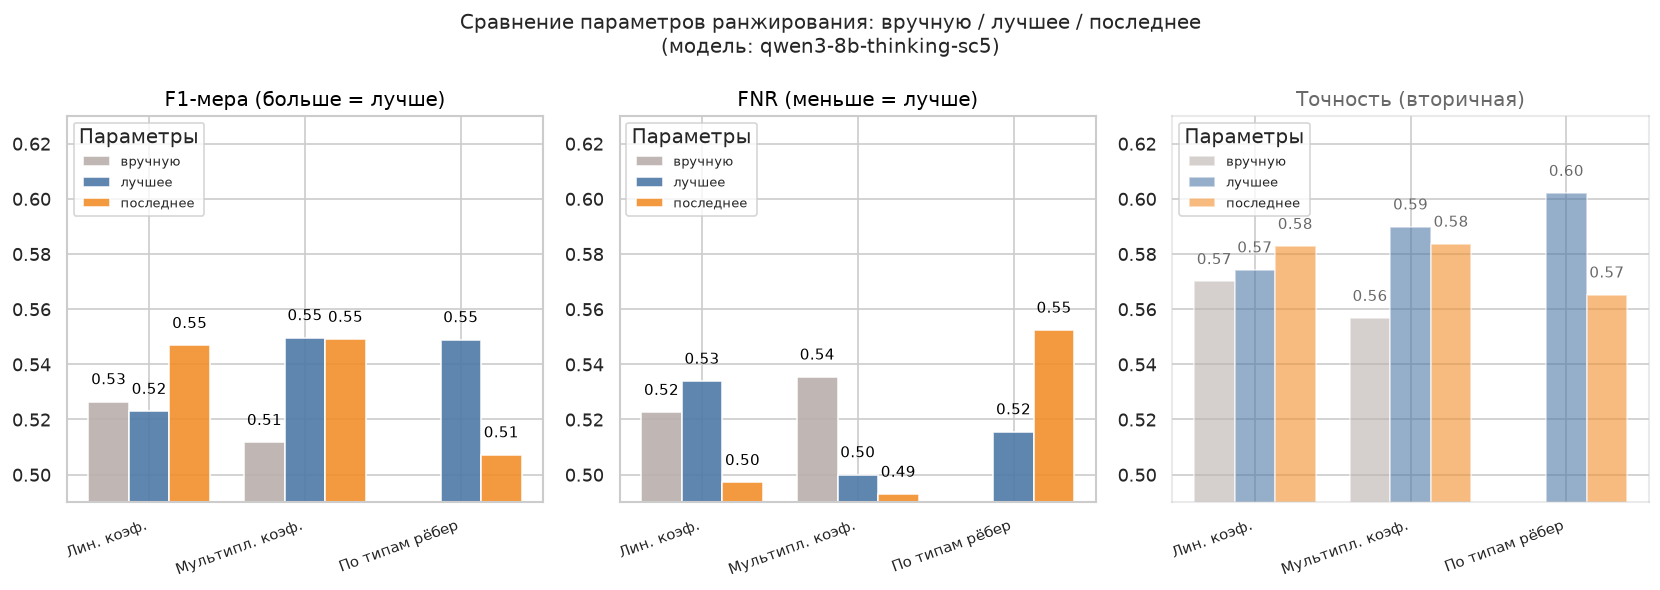

In [20]:
# Сгруппированная диаграмма: метрика по семействам, разбивка по варианту параметров

metrics_to_plot = [
    ('f1',       'F1-мера (больше = лучше)', False),
    ('FNR',      'FNR (меньше = лучше)',     False),
    ('accuracy', 'Точность (вторичная)',     True),
]
families = list(family_variants)
x     = np.arange(len(families))
width = 0.26

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, title, secondary) in zip(axes, metrics_to_plot):
    for i, variant in enumerate(VARIANT_ORDER):
        vals = []
        for fam in families:
            row = param_df[(param_df['family'] == fam) & (param_df['variant'] == variant)]
            vals.append(row[col].iloc[0] if len(row) else np.nan)
        offs = (i - (len(VARIANT_ORDER) - 1) / 2) * width
        bars = ax.bar(x + offs, vals, width, label=variant,
                      color=VARIANT_COLORS[variant],
                      alpha=0.6 if secondary else 0.9, edgecolor='white')
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=9,
                        color='dimgrey' if secondary else 'black')
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.49, 0.63)
    ax.set_title(title, fontsize=12, color='dimgrey' if secondary else 'black')
    ax.legend(title='Параметры', fontsize=8)
    if secondary:
        for spine in ax.spines.values():
            spine.set_alpha(0.4)

fig.suptitle(
    'Сравнение параметров ранжирования: вручную / лучшее / последнее\n'
    f'(модель: {MODEL_NAME})',
    fontsize=12,
)
fig.tight_layout()
plt.show()

In [8]:
# Выбор лучшего варианта в каждом семействе: максимум F1, при равенстве — минимум FNR

def pick_winner(variants):
    'Return (variant_name, info) with highest F1, tie-break lowest FNR.'
    return max(
        variants.items(),
        key=lambda kv: (round(kv[1]['metrics']['f1'], 6), -round(kv[1]['metrics']['FNR'], 6)),
    )

# SELECTED: display label -> info (one winning variant per tuned family)
SELECTED = {}
print('Выбранные победители семейств (по F1, при равенстве — по FNR):')
for family, variants in family_variants.items():
    win_variant, win_info = pick_winner(variants)
    SELECTED[f'{family} ({win_variant})'] = win_info
    others = '   '.join(
        f"{v}: F1={variants[v]['metrics']['f1']:.4f}"
        for v in VARIANT_ORDER if v in variants
    )
    print(f"  {family:>22}  ->  {win_variant:<10}  "
          f"F1={win_info['metrics']['f1']:.4f}  FNR={win_info['metrics']['FNR']:.4f}   "
          f"[{others}]")

# Comparison set for all later sections: family winners + non-tuned approaches.
COMPARISON = dict(SELECTED)
for display_name, info in non_tuned_data.items():
    COMPARISON[display_name] = info

print(f"\nИтоговый набор для базового сравнения: {len(COMPARISON)} стратегий")

Выбранные победители семейств (по F1, при равенстве — по FNR):
              Лин. коэф.  ->  последнее   F1=0.5469  FNR=0.4972   [вручную: F1=0.5265   лучшее: F1=0.5230   последнее: F1=0.5469]
         Мультипл. коэф.  ->  лучшее      F1=0.5497  FNR=0.5000   [вручную: F1=0.5117   лучшее: F1=0.5497   последнее: F1=0.5491]
          По типам рёбер  ->  лучшее      F1=0.5490  FNR=0.5156   [лучшее: F1=0.5490   последнее: F1=0.5072]

Итоговый набор для базового сравнения: 6 стратегий


## Базовое сравнение — F1 и FNR (первичные), точность (вторичная)

Сравниваются победители настраиваемых семейств (по одному варианту на семейство) и
ненастраиваемые стратегии. Панели F1 и FNR несут основной сигнал; точность показана
для справки с приглушённым оформлением.

In [9]:
# Сводная таблица метрик по выбранным стратегиям (сортировка по F1)

agg_df = (
    pd.DataFrame([{'approach': label, **info['metrics']} for label, info in COMPARISON.items()])
      .sort_values('f1', ascending=False)
      .reset_index(drop=True)
)
approaches_by_f1 = agg_df['approach'].tolist()

display(
    agg_df[['approach', 'n_runs', 'TP', 'TN', 'FP', 'FN',
            'f1', 'FNR', 'recall', 'accuracy', 'precision', 'FPR', 'MCC']]
    .round(4)
    .style
    .background_gradient(subset=['f1', 'MCC'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['recall'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['accuracy'], cmap='Greys', axis=0)
    .format('{:.4f}', subset=['f1', 'FNR', 'recall', 'accuracy', 'precision', 'FPR', 'MCC'])
)

,approach,n_runs,TP,TN,FP,FN,f1,FNR,recall,accuracy,precision,FPR,MCC
0,Мультипл. коэф. (лучшее),1,177,240,113,177,0.5497,0.5000,0.5000,0.5898,0.6103,0.3201,0.1829
1,По типам рёбер (лучшее),1,171,254,99,182,0.5490,0.5156,0.4844,0.6020,0.6333,0.2805,0.2098
2,Лин. коэф. (последнее),1,178,234,119,176,0.5469,0.4972,0.5028,0.5827,0.5993,0.3371,0.1679
3,Повторы и глубина,1,169,244,109,185,0.5348,0.5226,0.4774,0.5842,0.6079,0.3088,0.1726
4,Случайный выбор,1,172,230,124,182,0.5292,0.5141,0.4859,0.5678,0.5811,0.3503,0.1375
5,Последовательно,1,158,238,116,195,0.5040,0.5524,0.4476,0.5601,0.5766,0.3277,0.1231


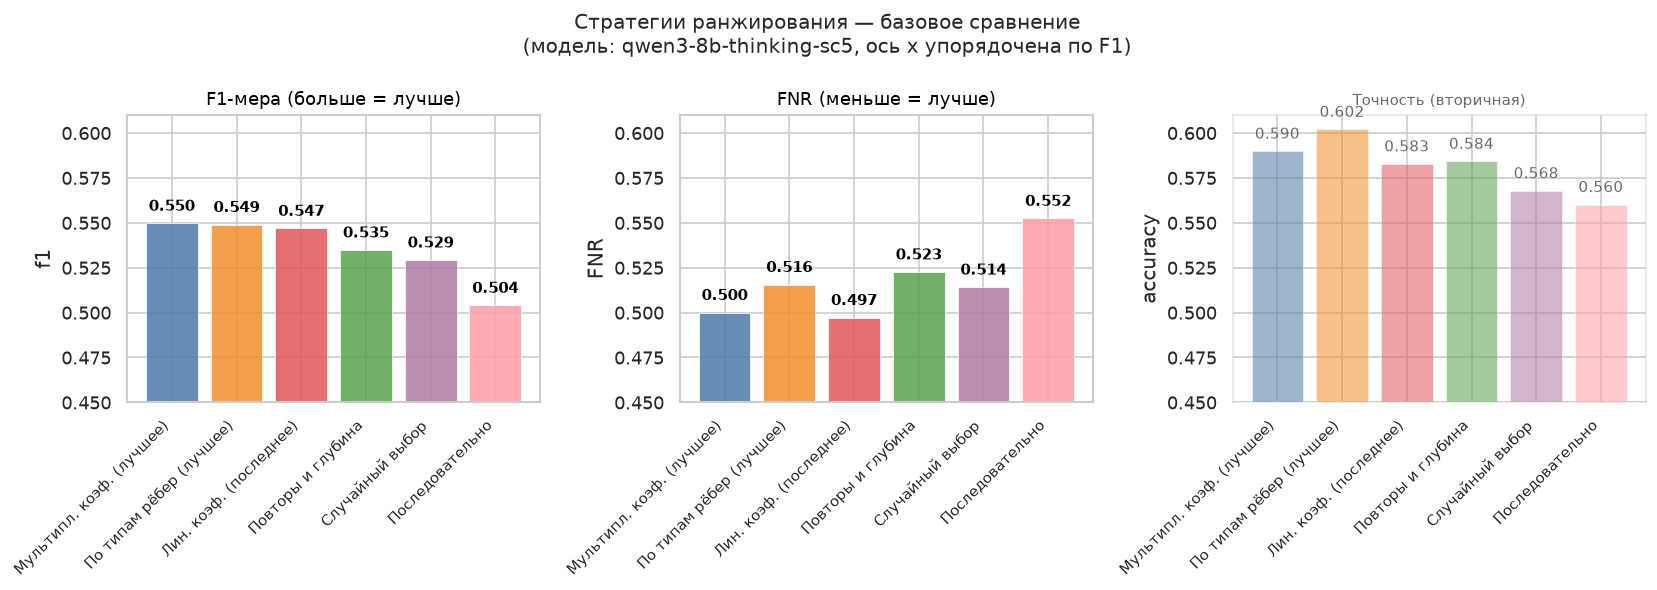

In [25]:
# Диаграмма: F1 (первичная) + FNR (первичная) + точность (вторичная)

ordered = agg_df.set_index('approach').loc[approaches_by_f1]
names   = approaches_by_f1
colors  = APPROACH_COLORS[:len(names)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
panels = [
    ('f1',       'F1-мера (больше = лучше)', 0.85, 11, False),
    ('FNR',      'FNR (меньше = лучше)',     0.85, 11, False),
    ('accuracy', 'Точность (вторичная)',     0.55,  9, True),
]
for ax, (col, title, alpha, title_fs, secondary) in zip(axes, panels):
    vals = ordered[col].values
    bars = ax.bar(names, vals, color=colors, alpha=alpha, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if not secondary else 'normal',
                color='dimgrey' if secondary else 'black')
    ax.set_ylim(0.45, 0.61)
    ax.set_title(title, fontsize=title_fs, color='dimgrey' if secondary else 'black')
    ax.set_ylabel(col)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    if secondary:
        for spine in ax.spines.values():
            spine.set_alpha(0.4)

fig.suptitle(
    f'Стратегии ранжирования — базовое сравнение\n'
    f'(модель: {MODEL_NAME}, ось x упорядочена по F1)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

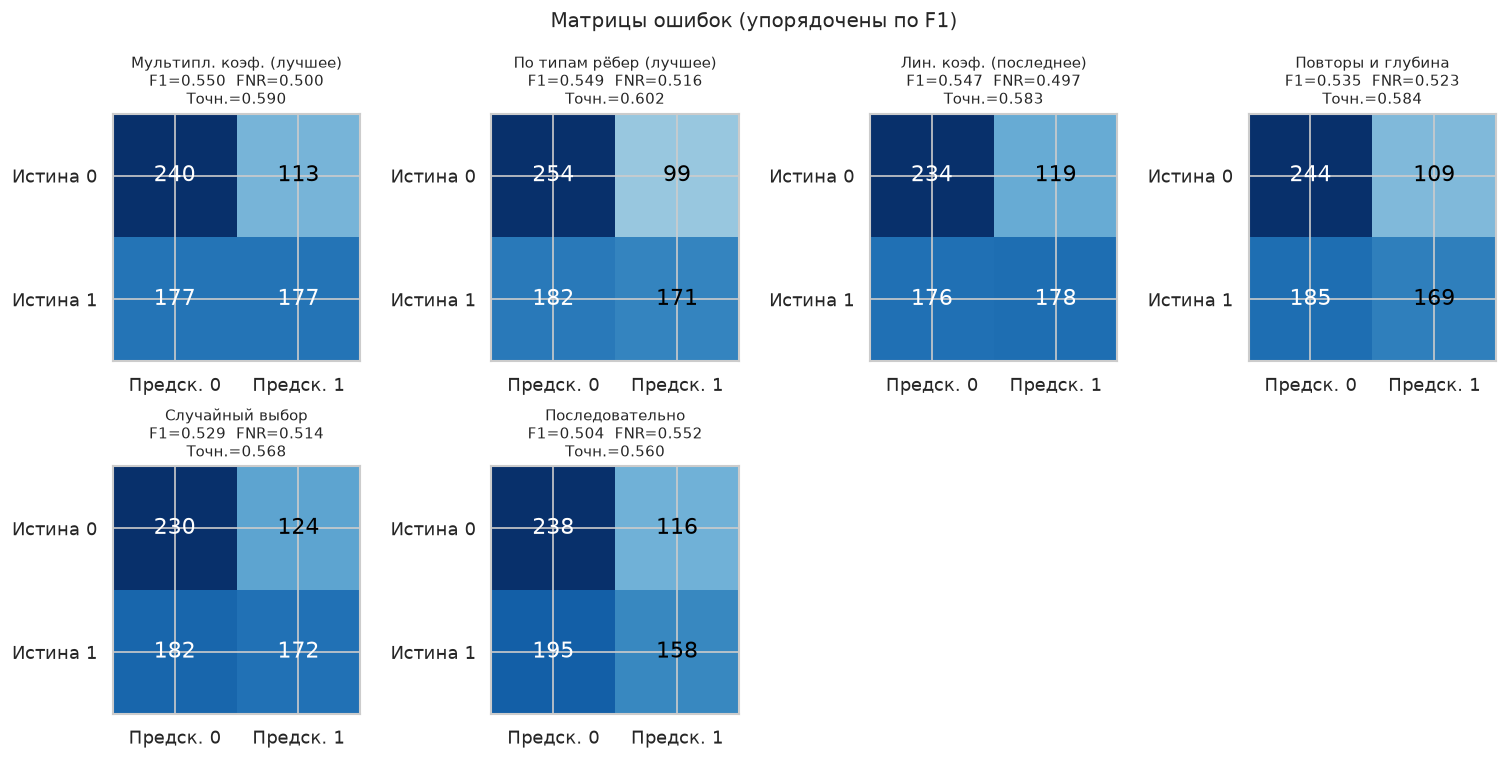

In [11]:
# Матрицы ошибок (упорядочены по F1)

ordered = agg_df.set_index('approach').loc[approaches_by_f1].reset_index()
n_ap  = len(ordered)
ncols = min(4, n_ap)
nrows = math.ceil(n_ap / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.2))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, ordered.iterrows()):
    cm_arr = np.array([[row['TN'], row['FP']],
                       [row['FN'], row['TP']]])
    ax.imshow(cm_arr, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(int(cm_arr[i, j])), ha='center', va='center', fontsize=13,
                    color='black' if cm_arr[i, j] < cm_arr.max() * 0.7 else 'white')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Предск. 0', 'Предск. 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Истина 0', 'Истина 1'])
    ax.set_title(
        f"{row['approach']}\n"
        f"F1={row['f1']:.3f}  FNR={row['FNR']:.3f}\n"
        f"Точн.={row['accuracy']:.3f}",
        fontsize=9,
    )
for ax in axes[n_ap:]:
    ax.set_visible(False)

fig.suptitle('Матрицы ошибок (упорядочены по F1)', fontsize=12)
fig.tight_layout()
plt.show()

## Итоги

In [12]:
# Лидеры по метрикам среди выбранных стратегий

best_f1  = agg_df.loc[agg_df['f1'].idxmax()]
best_fnr = agg_df.loc[agg_df['FNR'].idxmin()]
best_acc = agg_df.loc[agg_df['accuracy'].idxmax()]

print('=== Первичные метрики ===')
print(f"Наибольший F1  : {best_f1['approach']:>28}  "
      f"F1={best_f1['f1']:.4f}  FNR={best_f1['FNR']:.4f}  точн.={best_f1['accuracy']:.4f}")
print(f"Наименьший FNR : {best_fnr['approach']:>28}  "
      f"FNR={best_fnr['FNR']:.4f}  F1={best_fnr['f1']:.4f}  точн.={best_fnr['accuracy']:.4f}")
print()
print('=== Вторичная метрика ===')
print(f"Наибольшая точность: {best_acc['approach']:>28}  "
      f"точн.={best_acc['accuracy']:.4f}  F1={best_acc['f1']:.4f}  FNR={best_acc['FNR']:.4f}")

print()
print('=== Выбор гиперпараметров по семействам ===')
for family, variants in family_variants.items():
    win_variant, _ = pick_winner(variants)
    parts = '   '.join(
        f"{v}: F1={variants[v]['metrics']['f1']:.4f} FNR={variants[v]['metrics']['FNR']:.4f}"
        for v in VARIANT_ORDER if v in variants
    )
    print(f"{family:>22}  ->  лучший: {win_variant:<10}  [{parts}]")

=== Первичные метрики ===
Наибольший F1  :     Мультипл. коэф. (лучшее)  F1=0.5497  FNR=0.5000  точн.=0.5898
Наименьший FNR :       Лин. коэф. (последнее)  FNR=0.4972  F1=0.5469  точн.=0.5827

=== Вторичная метрика ===
Наибольшая точность:      По типам рёбер (лучшее)  точн.=0.6020  F1=0.5490  FNR=0.5156

=== Выбор гиперпараметров по семействам ===
            Лин. коэф.  ->  лучший: последнее   [вручную: F1=0.5265 FNR=0.5226   лучшее: F1=0.5230 FNR=0.5339   последнее: F1=0.5469 FNR=0.4972]
       Мультипл. коэф.  ->  лучший: лучшее      [вручную: F1=0.5117 FNR=0.5354   лучшее: F1=0.5497 FNR=0.5000   последнее: F1=0.5491 FNR=0.4929]
        По типам рёбер  ->  лучший: лучшее      [лучшее: F1=0.5490 FNR=0.5156   последнее: F1=0.5072 FNR=0.5524]


In [27]:
# Сводная таблица: метрики по стратегиям + кросс-статистика
#
# В отличие от базового сравнения (где для настраиваемых семейств берётся только
# вариант-победитель), итоговая таблица показывает ВСЕ варианты настройки параметров —
# вручную / лучшее / последнее — для каждого семейства, плюс ненастраиваемые стратегии.

final_set = {}
for family, variants in family_variants.items():
    for variant in VARIANT_ORDER:
        if variant in variants:
            final_set[f'{family} ({variant})'] = variants[variant]
for display_name, info in non_tuned_data.items():
    final_set[display_name] = info

final_df = (
    pd.DataFrame([{'approach': label, **info['metrics']} for label, info in final_set.items()])
      .sort_values('f1', ascending=False)
      .reset_index(drop=True)
)
final_by_f1 = final_df['approach'].tolist()

summary_cols = ['f1', 'FNR', 'recall', 'accuracy', 'precision', 'FPR',
                'MCC', 'TP', 'TN', 'FP', 'FN']
totals_df = final_df.set_index('approach')[summary_cols].copy()
totals_df['n_samples'] = totals_df[['TP', 'TN', 'FP', 'FN']].sum(axis=1).astype(int)

higher_better = ['f1', 'recall', 'accuracy', 'precision', 'MCC', 'TP', 'TN']
lower_better  = ['FNR', 'FPR', 'FP', 'FN']
numeric_cols  = higher_better + lower_better + ['n_samples']

def _best(col):
    return totals_df[col].max() if col in higher_better else totals_df[col].min()

def _worst(col):
    return totals_df[col].min() if col in higher_better else totals_df[col].max()

footer_rows = {
    'СРЕДНЕЕ': {c: totals_df[c].mean()   for c in numeric_cols},
    'МЕДИАНА': {c: totals_df[c].median() for c in numeric_cols},
    'ЛУЧШЕЕ':  {c: _best(c)  for c in numeric_cols},
    'ХУДШЕЕ':  {c: _worst(c) for c in numeric_cols},
    'РАЗМАХ':  {c: totals_df[c].max() - totals_df[c].min() for c in numeric_cols},
}
footer_df = pd.DataFrame(footer_rows).T
footer_idx = list(footer_rows)

combined = pd.concat([totals_df, footer_df], axis=0)
combined.index.name = 'стратегия / стат.'

# RESULTS_DIR is owned by root (written by Docker); save the CSV next to the notebook.
CSV_PATH = PROJECT_ROOT / 'benchmarks' / 'compare_rankings_vllm_summary.csv'
combined.to_csv(CSV_PATH, float_format='%.3f')
print(f'Сводка сохранена в: {CSV_PATH}')

def _fmt_int_or_float(v):
    if pd.isna(v):
        return ''
    if float(v).is_integer():
        return f'{int(v)}'
    return f'{v:.1f}'

frac_cols  = ['f1', 'FNR', 'recall', 'accuracy', 'precision', 'FPR', 'MCC']
count_cols = ['TP', 'TN', 'FP', 'FN', 'n_samples']

display(
    combined
    .style
    .background_gradient(subset=pd.IndexSlice[final_by_f1, ['f1', 'MCC']],
                         cmap='RdYlGn', axis=0)
    .background_gradient(subset=pd.IndexSlice[final_by_f1, ['FNR', 'FPR']],
                         cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=pd.IndexSlice[final_by_f1, ['recall']],
                         cmap='RdYlGn', axis=0)
    .background_gradient(subset=pd.IndexSlice[final_by_f1, ['accuracy']],
                         cmap='Greys', axis=0)
    .set_properties(subset=pd.IndexSlice[footer_idx, :],
                    **{'background-color': '#f4f4f4', 'font-weight': 'bold'})
    .format('{:.3f}', subset=frac_cols, na_rep='')
    .format(_fmt_int_or_float, subset=count_cols, na_rep='')
)

Сводка сохранена в: /var/opt/llm4codesec-framework/benchmarks/compare_rankings_vllm_summary.csv


,f1,FNR,recall,accuracy,precision,FPR,MCC,TP,TN,FP,FN,n_samples
стратегия / стат.,,,,,,,,,,,,
Мультипл. коэф. (лучшее),0.550,0.500,0.500,0.590,0.610,0.320,0.183,177,240,113,177,707
Мультипл. коэф. (последнее),0.549,0.493,0.507,0.584,0.599,0.340,0.169,179,233,120,174,706
По типам рёбер (лучшее),0.549,0.516,0.484,0.602,0.633,0.280,0.210,171,254,99,182,706
Лин. коэф. (последнее),0.547,0.497,0.503,0.583,0.599,0.337,0.168,178,234,119,176,707
Повторы и глубина,0.535,0.523,0.477,0.584,0.608,0.309,0.173,169,244,109,185,707
Случайный выбор,0.529,0.514,0.486,0.568,0.581,0.350,0.137,172,230,124,182,708
Лин. коэф. (вручную),0.526,0.523,0.477,0.570,0.587,0.337,0.143,169,234,119,185,707
Лин. коэф. (лучшее),0.523,0.534,0.466,0.574,0.596,0.317,0.152,165,241,112,189,707
Мультипл. коэф. (вручную),0.512,0.535,0.465,0.557,0.569,0.351,0.115,164,229,124,189,706
